[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/astheeggeggs/testing_colab/blob/main/rare_variant_Fisher_test.ipynb)

# 🎣 Fisher's Exact Tests

In this section, you'll be running a collection of Fisher's exact tests and plotting the results. The data you will be analysing represents a subset of genes in a bipolar exome sequencing analysis.

The genetic and phenotypic data has been rigorously quality controlled. You can review the quality control pipeline [here](https://astheeggeggs.github.io/BipEx/qc.html). The cohort has been restricted to unrelated individuals with European genetic ancestry.

Before we start, let's grab all of the files for this practical:
---

In [1]:
!python -m pip -q install gdown
!gdown --folder https://drive.google.com/drive/folders/1oBQ46iz8B3DBbb3hm1-Y1pmyw0Pkp-_R?usp=drive_link -O /content/

Retrieving folder contents
Processing file 17INL6CXNBVJKKRz8FvTCDTwabLBGRYeK dataset_1.tsv.gz
Processing file 1QGW5pDJydUxeMuRhvYDASl_9_3rYeZbo dataset_2.tsv.gz
Processing file 1QECmSihB-kY2TKLaiWEhlGYj5g9Q1Hrb gene_mapping_to_extract.tsv.gz
Processing file 1MuuXldCbnWBUkFicViO_5-bzrxnLwNb0 gene_names_to_extract.tsv.gz
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=17INL6CXNBVJKKRz8FvTCDTwabLBGRYeK
To: /content/Fisher/dataset_1.tsv.gz
100% 103k/103k [00:00<00:00, 108MB/s]
Downloading...
From: https://drive.google.com/uc?id=1QGW5pDJydUxeMuRhvYDASl_9_3rYeZbo
To: /content/Fisher/dataset_2.tsv.gz
100% 228k/228k [00:00<00:00, 134MB/s]
Downloading...
From: https://drive.google.com/uc?id=1QECmSihB-kY2TKLaiWEhlGYj5g9Q1Hrb
To: /content/Fisher/gene_mapping_to_extract.tsv.gz
100% 1.02M/1.02M [00:00<00:00, 159MB/s]
Downloading...
From: https://drive.google.com/uc?id=1MuuXldCbnWBUkFicViO_5-

## 🔍 Quality Control (QC) Discussion

Briefly discuss the QC carried out on the exome sequencing data in the [linked pipeline](https://www.google.com/url?q=https%3A%2F%2Fastheeggeggs.github.io%2FBipEx%2Fqc.html).

Take a look through and convince yourselves that these QC steps are reasonable.

We've counted the number of individuals with an extremely rare (MAC < 5, and not present in the non-psych portion of gnomAD) pLoF or damaging missense variant in each gene, split by case status, and saved the results to a file named `dataset_1.tsv.gz`.

Take a look at these counts by using head or less on the file `dataset_1.tsv.gz`. (Note that you'll need to use `zcat` or `zless`).

In [2]:
!zcat /content/Fisher/dataset_1.tsv.gz | head

gene_id	damaging_missense_fisher_gnom_non_psych_case_count	damaging_missense_fisher_gnom_non_psych_control_count	ptv_fisher_gnom_non_psych_case_count	ptv_fisher_gnom_non_psych_control_count
ENSG00000000003	1	0	0	0
ENSG00000000005	0	1	1	2
ENSG00000000419	2	2	4	2
ENSG00000000457	4	9	5	5
ENSG00000000460	4	7	8	4
ENSG00000000938	8	2	3	2
ENSG00000000971	16	4	1	1
ENSG00000001036	4	5	5	7
ENSG00000001084	1	6	2	1


### ❓ Question 1.1
Using these data, what hypotheses might we want to test?

<details>
  <summary>💡 Click here to reveal!</summary>
  
  One primary series of tests we could perform is to look for evidence of an association between the presence of a pLoF in an individual and their case status, evaluated at the gene-level.
</details>

### ❓ Question 1.2
What class of variation could you use as a negative control?

* Synonymous variation
* Missense variation
* Non-coding variation
* Synonymous variation with MAC < 5, and not in gnomAD non-psych

<details>
  <summary>💡 Click here to reveal!</summary>
  
  **Synonymous variation with MAC < 5, and not in gnomAD non-psych** is the best negative control, as it perfectly mirrors the frequency architecture and filtering steps of our test variants, but lacks the presumed biological consequence (protein-truncation).
</details>

Let's test for an association between presence of a pLoF in an individual and case status in a subset of these genes using Fisher's exact tests. In particular, we'll extract the collection of genes in `gene_names_to_extract.tsv.gz`.

> ⚠️ **Wait!** The file `dataset_1.tsv.gz` has the gene IDs saved as Ensembl IDs. What idiot sent you this gene list anyway?

### ❓ Question 1.3
Can you use the mapping file provided in the `Fisher` folder (`gene_mapping_to_extract.tsv.gz`) to map the gene symbols onto Ensembl IDs and then restrict to the genes in `gene_names_to_extract.tsv.gz`?

You can choose to do this in whatever programming language you like. We've provided an example script in R below. Before running it, think about how you would execute this join yourself.

In [3]:
# Load the R magic extension so we can write native R inside this notebook
%load_ext rpy2.ipython

In [34]:
%%R
library(data.table)
library(dplyr)

setwd("/content/Fisher")

# Merge and restrict to the 100 genes listed in gene_names_to_extract.tsv.gz.
dt_to_extract <- fread(cmd = "zcat gene_names_to_extract.tsv.gz", header=FALSE)
dt_map <- fread(cmd = "zcat gene_mapping_to_extract.tsv.gz")
dt <- fread(cmd = "zcat dataset_1.tsv.gz", sep='\t')

dt_to_extract <- dt_to_extract %>% mutate(gene_name = V1)
setkey(dt_to_extract, "gene_name")
dt_map <- dt_map %>%
  dplyr::rename(gene_id = `Gene stable ID`, gene_name = `Gene name`)
setkey(dt_map, "gene_name")
dt_genes <- merge(dt_map, dt_to_extract) %>% dplyr::select(gene_id, gene_name)

setkey(dt_genes, "gene_id")
setkey(dt, "gene_id")

# Filter down to the set of genes present in the list passed
dt <- merge(dt_genes, dt)

Following the restriction, which are the first five gene names alphabetically?

<details>
  <summary>💡 Click to verify your top 5!</summary>
  
  1. *ACTL6B*
  2. *ADGRG3*
  3. *AKAP11*
  4. *ARL14EPL*
  5. *ASAP1*
</details>

In [35]:
%%R
setorder(dt, "gene_name")
print(head(dt, 5))

           gene_id gene_name damaging_missense_fisher_gnom_non_psych_case_count
            <char>    <char>                                              <int>
1: ENSG00000077080    ACTL6B                                                  6
2: ENSG00000182885    ADGRG3                                                  2
3: ENSG00000023516    AKAP11                                                  8
4: ENSG00000268223  ARL14EPL                                                  3
5: ENSG00000153317     ASAP1                                                  9
   damaging_missense_fisher_gnom_non_psych_control_count
                                                   <int>
1:                                                     4
2:                                                     3
3:                                                    14
4:                                                     1
5:                                                     8
   ptv_fisher_gnom_non_psych_case_count p

---
## 🧮 Running the Fisher's Exact Tests

Now, let's perform a series of Fisher's exact tests. First, we'll write a function to evaluate the data. You may assume that the number of total cases and controls is fixed for each gene:

$N_{cases} = 13,933$  
$N_{controls} = 14,422$

### ❓ Question 1.4
Given that information, can you create an R function that uses the two provided counts, runs a two-sided Fisher's exact test, and provides an odds ratio and $P$-value?

The function requires the following matrix layout:
| | Has pLoF | Does NOT have pLoF |
| :--- | :---: | :---: |
| **Case** | a | b |
| **Control** | c | d |

*(Note: You can make use of native R functions! Take a look at `?fisher.test`.)*

In [36]:
%%R
run_fisher_test <- function(case_var, control_var, n_cases=13933, n_controls=14422) {
  # create a 2x2 table of the inputted numbers
  mat <- matrix(
    c(case_var, n_cases - case_var, control_var, n_controls - control_var), nrow=2)
  # perform a Fisher's exact test
  f <- fisher.test(mat, alternative='two.sided')
  # return the result
  return(f)
}

Now, let's test whether there is an association between presence of a pLoF in the gene and case status for each of the 100 genes in `gene_names_to_extract.tsv.gz`.

We will generate a table containing the Gene name, $P$-value, and odds-ratio ($OR$) for each gene, and then sort by lowest $P$-value.

In [37]:
%%R
dt[, c("p_value", "odds_ratio") := {
  test <- run_fisher_test(
    ptv_fisher_gnom_non_psych_case_count,
    ptv_fisher_gnom_non_psych_control_count
  )
  list(test$p.value, test$estimate)
}, by = seq_len(nrow(dt))]  # Apply per row

dt_results <- dt %>% dplyr::select(gene_id, gene_name, p_value, odds_ratio)
head(dt_results[order(p_value)], 5)

           gene_id gene_name      p_value odds_ratio
            <char>    <char>        <num>      <num>
1: ENSG00000023516    AKAP11 1.150102e-05        Inf
2: ENSG00000083097     DOP1A 2.221591e-04 15.5442757
3: ENSG00000058804      NDC1 5.828607e-02        Inf
4: ENSG00000129595  EPB41L4A 7.231816e-02  2.8479521
5: ENSG00000011028      MRC2 1.802036e-01  0.2956758


---
### 🚀 Pro-Tip: Scaling up to Exome-Wide Analysis

For 100 genes, applying `fisher.test()` row-by-row in a loop is perfectly fast. But what happens when you need to compute Fisher's exact tests for all 20,000+ protein-coding genes? Base R's loop will start to bottleneck severely.

For massive datasets, bioinformaticians use **vectorization**. Instead of running the formal `fisher.test` loop, we can calculate the $P$-values mathematically in a single hyper-fast step using the underlying Hypergeometric distribution (`phyper`) or optimized C++ libraries like `Rfast`.

You do not need to run this for today's practical, but here is a freebie snippet showing how you would vectorize this calculation to run in less than a second!

In [38]:
%%R
# Example of a highly optimized, vectorized one-sided P-value calculation using phyper
fast_fisher_p_onesided <- function(case_var, control_var, n_cases=13933, n_controls=14422) {
  # q: number of case variants minus 1 (for upper tail)
  # m: total cases
  # n: total controls
  # k: total variants observed across both groups
  return(phyper(
    q = case_var - 1,
    m = n_cases,
    n = n_controls,
    k = case_var + control_var,
    lower.tail = FALSE
  ))
}

# This would run instantly on 20,000 genes without a loop!
dt_results_new <- dt[, fast_p_value := fast_fisher_p_onesided(
    ptv_fisher_gnom_non_psych_case_count,
    ptv_fisher_gnom_non_psych_control_count)]
setorder(dt_results_new, fast_p_value)
head(dt_results_new, 5)

           gene_id gene_name damaging_missense_fisher_gnom_non_psych_case_count
            <char>    <char>                                              <int>
1: ENSG00000023516    AKAP11                                                  8
2: ENSG00000083097     DOP1A                                                 21
3: ENSG00000129595  EPB41L4A                                                  9
4: ENSG00000058804      NDC1                                                  3
5: ENSG00000278505  C17orf78                                                  1
   damaging_missense_fisher_gnom_non_psych_control_count
                                                   <int>
1:                                                    14
2:                                                    15
3:                                                     2
4:                                                     2
5:                                                     0
   ptv_fisher_gnom_non_psych_case_count p

### ❓ Questions 1.5-1.7
**1.5:** What genes are in the top 5 rows of your table?

**1.6:** What would the Bonferroni significance threshold be, assuming that we plan to test *all* genes genome-wide, not just these 100?

**1.7:** Based on that threshold, are any of your associations actually significant?

<details>
  <summary>💡 Click to reveal the answers!</summary>
  
  **Top 5 Genes:** *AKAP11*, *DOP1A*, *NDC1*, *EPB41L4A*, *MRC2*.
  
  **Bonferroni Threshold:** $0.05 / 19,225 = 2.6 \times 10^{-6}$ (assuming roughly 19,225 protein-coding genes in the genome).
  
  **Are they significant?:** No! Our top hit (*AKAP11*) has a $P$-value of $1.15 \times 10^{-5}$, which does not survive genome-wide multiple testing correction.
</details>

---
## 📊 QQ Plots and Distribution Diagnostics

We've provided another file containing the associated $P$-values for *all* genes: `dataset_2.tsv.gz`.

### ❓ Question 1.8
Can you create a QQ plot of the $P$-values for these results? Run the `ggplot2` cell below to visualize the distribution against expectation.

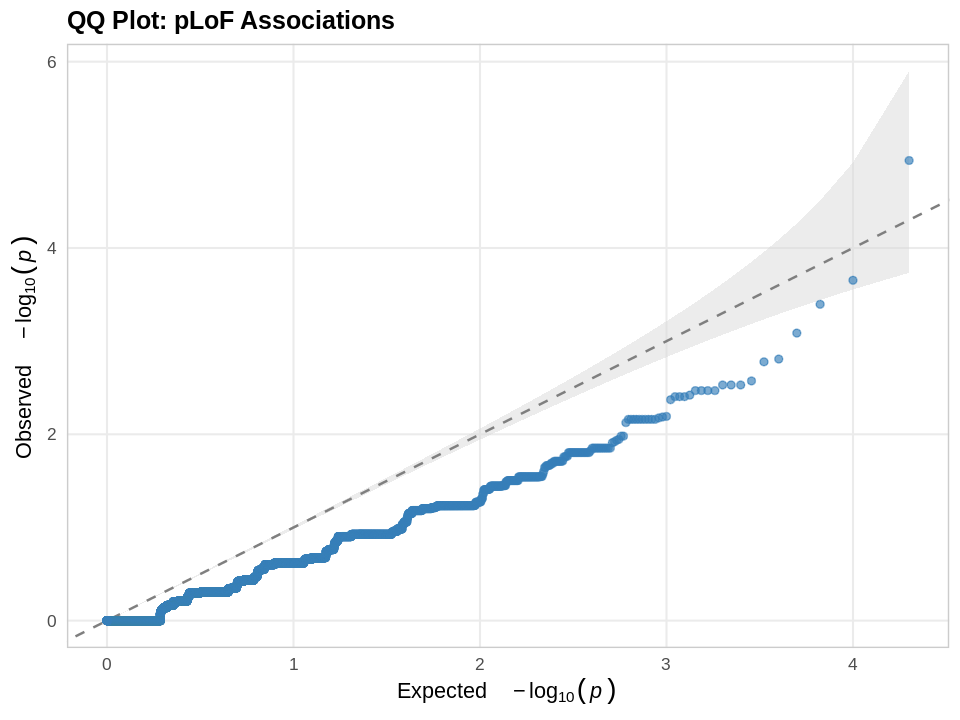

In [40]:
%%R -w 8 -h 6 --units in -r 120
library(ggplot2)
library(dplyr)
library(data.table)

dt2 <- fread(cmd = "zcat dataset_2.tsv.gz")

# Calculate expected P-values and 95% Confidence Intervals based on mathematical rank
plot_data <- dt2 %>%
  arrange(plof_p_value) %>%
  mutate(
    rank = row_number(),
    n_total = n(),
    Pvalue_exp = rank / (n_total + 1),
    lower_ci = qbeta(0.025, rank, n_total - rank + 1),
    upper_ci = qbeta(0.975, rank, n_total - rank + 1)
  )

ggplot(plot_data, aes(x = -log10(Pvalue_exp))) +
  geom_ribbon(aes(ymin = -log10(upper_ci), ymax = -log10(lower_ci)), fill = "grey85", alpha = 0.5) +
  geom_abline(intercept = 0, slope = 1, color = "grey50", linetype = "dashed", linewidth = 0.7) +
  geom_point(aes(y = -log10(plof_p_value)), size = 1.8, alpha = 0.65, color = "#377eb8") +
  theme_minimal(base_size = 13) +
  theme(
    panel.border = element_rect(color = "grey80", fill = NA, linewidth = 0.8),
    panel.grid.minor = element_blank(),
    plot.title = element_text(face = "bold", size = 15, margin = margin(b = 6))
  ) +
  labs(
    title = "QQ Plot: pLoF Associations",
    x = expression(Expected~~-log[10](italic(p))),
    y = expression(Observed~~-log[10](italic(p)))
  )

### 🧠 QQ Plot Discussion
What does the QQ plot look like? Does it seem reasonable? How are you assuming that $P$-values are sampled under the null? Why do you think there are 'steps' in the QQ plot?

<details>
  <summary>💡 Click to reveal the explanation!</summary>
  
  You likely noticed that the points sit below the $y=x$ line and look very "steppy" or discretized.
  
  We assume that under the null hypothesis, $P$-values should be uniformly distributed $U(0,1)$. However, rare variants have incredibly low raw counts. Because the Fisher's exact test operates on a $2 \times 2$ contingency table of integers, there are only so many discrete $P$-values it can physically compute (e.g., you can't have 1.5 cases). This quantization forces the $P$-values into discrete mathematical "steps" rather than a smooth continuous uniform distribution.
</details>

### 👀 Visualizing the "Steps"
To really understand this quantization effect, let's mathematically simulate a perfectly continuous uniform distribution $U(0,1)$ and plot it directly behind your Fisher's $P$-values so you can explicitly see the missing gaps where the discrete math breaks down!

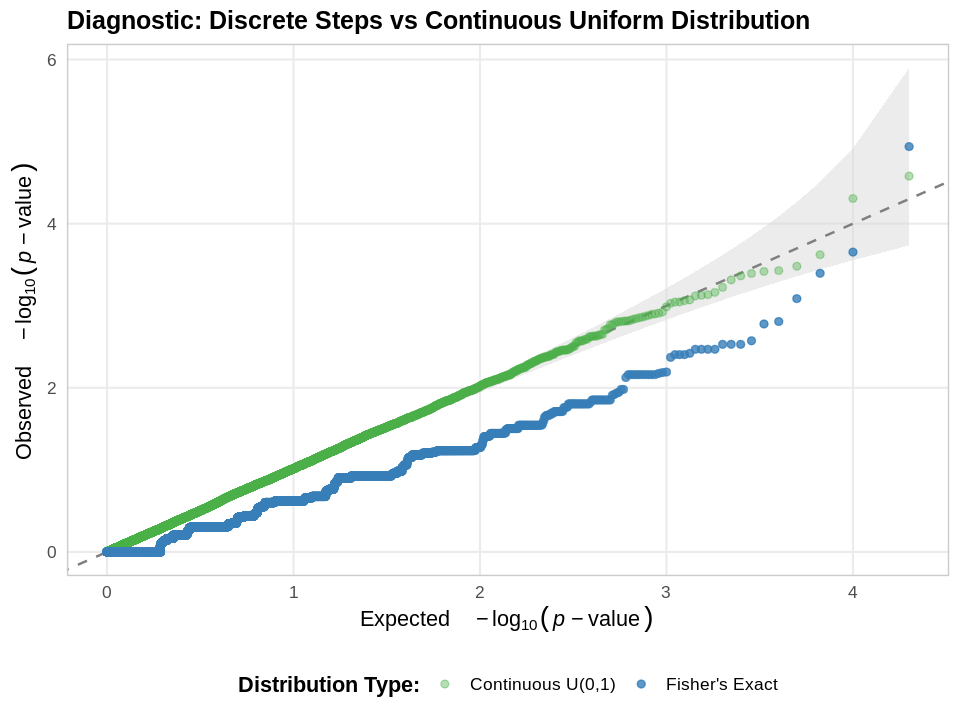

In [45]:
%%R -w 8 -h 6 --units in -r 120
set.seed(42)

# Generate a standalone, pre-sorted array of uniform random numbers
sorted_uniform_p <- sort(runif(nrow(plot_data)))

# Attach it cleanly to our existing data
plot_data_sim <- plot_data %>%
  # We don't need to arrange the whole table, just drop the sorted array in!
  mutate(continuous_p_sorted = sorted_uniform_p)

ggplot(plot_data_sim, aes(x = -log10(Pvalue_exp))) +
  geom_ribbon(aes(ymin = -log10(upper_ci), ymax = -log10(lower_ci)), fill = "grey85", alpha = 0.5) +
  geom_abline(intercept = 0, slope = 1, color = "grey50", linetype = "dashed", linewidth = 0.7) +

  # Plot the perfect continuous background in Green (Now it will form a tight line!)
  geom_point(aes(y = -log10(continuous_p_sorted), color = "Continuous U(0,1)"), size = 1.8, alpha = 0.4) +

  # Plot the discrete Fisher steps in Blue
  geom_point(aes(y = -log10(plof_p_value), color = "Fisher's Exact"), size = 1.8, alpha = 0.8) +

  scale_color_manual(name = "Distribution Type:", values = c("Continuous U(0,1)" = "#4daf4a", "Fisher's Exact" = "#377eb8")) +
  theme_minimal(base_size = 13) +
  theme(
    panel.border = element_rect(color = "grey80", fill = NA, linewidth = 0.8),
    panel.grid.minor = element_blank(),
    legend.position = "bottom",
    legend.title = element_text(face = "bold"),
    plot.title = element_text(face = "bold", size = 15, margin = margin(b = 6))
  ) +
  labs(
    title = "Diagnostic: Discrete Steps vs Continuous Uniform Distribution",
    x = expression(Expected~~-log[10](italic(p))),
    y = expression(Observed~~-log[10](italic(p)))
  )

### ❓ Question 1.9
What happens if you filter to the set of genes for which at least 10 individuals have a variant in the gene? Does it look more 'calibrated'? Run the code below.

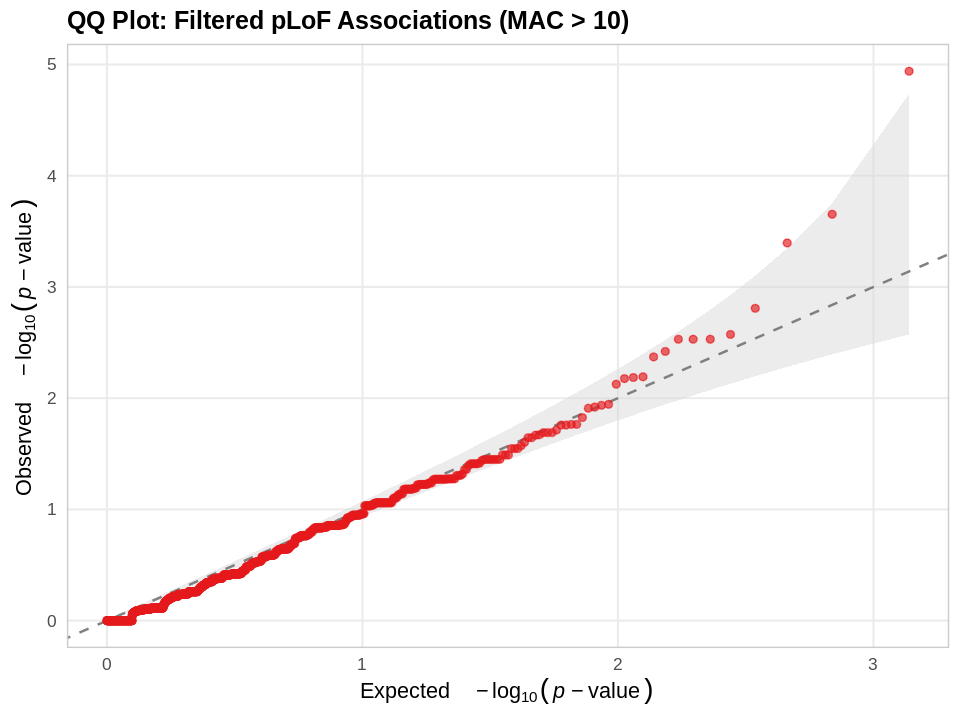

In [42]:
%%R -w 8 -h 6 --units in -r 120
# Filter to genes with Total Count > 10
plot_data_filtered <- dt2 %>%
  filter((plof_fisher_gnom_non_psych_control_count + plof_fisher_gnom_non_psych_case_count) > 10) %>%
  arrange(plof_p_value) %>%
  mutate(
    rank = row_number(),
    n_total = n(),
    Pvalue_exp = rank / (n_total + 1),
    lower_ci = qbeta(0.025, rank, n_total - rank + 1),
    upper_ci = qbeta(0.975, rank, n_total - rank + 1)
  )

ggplot(plot_data_filtered, aes(x = -log10(Pvalue_exp))) +
  geom_ribbon(aes(ymin = -log10(upper_ci), ymax = -log10(lower_ci)), fill = "grey85", alpha = 0.5) +
  geom_abline(intercept = 0, slope = 1, color = "grey50", linetype = "dashed", linewidth = 0.7) +
  geom_point(aes(y = -log10(plof_p_value)), size = 1.8, alpha = 0.65, color = "#e41a1c") +
  theme_minimal(base_size = 13) +
  theme(
    panel.border = element_rect(color = "grey80", fill = NA, linewidth = 0.8),
    panel.grid.minor = element_blank(),
    plot.title = element_text(face = "bold", size = 15, margin = margin(b = 6))
  ) +
  labs(
    title = "QQ Plot: Filtered pLoF Associations (MAC > 10)",
    x = expression(Expected~~-log[10](italic(p))),
    y = expression(Observed~~-log[10](italic(p)))
  )

---
## 🧪 Optional Section: The Cauchy Combination Test

Another researcher took a look at the first dataset that you analysed and thought that it would be a great idea to *also* analyse damaging missense variation.

This seems like a good idea, but would normally require accounting for double the number of tests in your Bonferroni correction. They suggest performing a **Cauchy combination test** instead, which allows you to aggregate as many tests as you like while maintaining the same effective number of tests!

Using the following provided R code, we can determine the Cauchy combination $P$-values for each gene:

In [43]:
%%R
CCT <- function(pvals, weights=NULL) {
  if (sum(is.na(pvals)) > 0) stop("Cannot have NAs in the p-values!")
  if ((sum(pvals < 0) + sum(pvals > 1)) > 0) stop("All p-values must be between 0 and 1!")

  is.zero <- (sum(pvals == 0) >= 1)
  is.one <- (sum(pvals == 1) >= 1)

  if (is.zero) return(0)
  if (is.one) {
    warning("There are p-values that are exactly 1!")
    return(min(1, min(pvals)*length(pvals)))
  }

  if (is.null(weights)){
    weights <- rep(1/length(pvals), length(pvals))
  } else if (length(weights) != length(pvals)) {
    stop("The length of weights should be the same as that of the p-values!")
  } else if (sum(weights < 0) > 0) {
    stop("All the weights must be positive!")
  } else {
    weights <- weights / sum(weights)
  }

  is.small <- pvals < 1e-16
  if (sum(is.small) == 0) {
    cct.stat <- sum(weights * tan((0.5 - pvals)*pi))
  } else {
    cct.stat <- sum((weights[is.small] / pvals[is.small]) / pi)
    cct.stat <- cct.stat + sum(weights[!is.small] * tan((0.5 - pvals[!is.small]) * pi))
  }

  if (cct.stat > 1e+15) {
    pval <- (1 / cct.stat) / pi
  } else {
    pval <- 1 - pcauchy(cct.stat)
  }
  return(pval)
}

dt2[, cauchy_p := CCT(c(plof_p_value, damaging_missense_p_value)), by = seq_len(nrow(dt2))]

               gene_id plof_fisher_gnom_non_psych_control_count
                <char>                                    <int>
    1: ENSG00000000003                                        0
    2: ENSG00000000005                                        2
    3: ENSG00000000419                                        2
    4: ENSG00000000457                                        5
    5: ENSG00000000460                                        4
   ---                                                         
19989: ENSG00000285959                                        0
19990: ENSG00000285976                                        0
19991: ENSG00000285978                                        0
19992: ENSG00000285982                                        3
19993: ENSG00000285991                                        2
       plof_fisher_gnom_non_psych_case_count
                                       <int>
    1:                                     0
    2:                           

In addition: There were 50 or more warnings (use warnings() to see the first 50)


### ❓ Questions 1.10-1.12
**1.10:** Are there any genes which become significant in the Cauchy combination test that were not significant in either the pLoF or damaging missense tests? Why?

**1.11:** What would happen if you Cauchy combined exactly the same P-values? (You can test this using `runif`!)

**1.12:** Under what scenarios might it be a good idea to use a Cauchy combination test?

<details>
  <summary>💡 Click to reveal the Cauchy secrets!</summary>
  
  **1.10:** No. There are no associations that are exome-wide significant in the damaging missense class of variation, and the test statistic for the Cauchy combination test guarantees that it is mathematically impossible to get a lower $P$-value than the absolute minimum of the individual $P$-values being combined.
  
  **1.11:** You just get back exactly what you put in! Because it acts as an aggregator of distribution mass, combining perfectly identical values yields the same exact statistical weight.
  
  **1.12:** It is brilliant when you have a bunch of tests that are highly *correlated* but not perfectly identical. A classic example is combining tests across different, slightly overlapping allele frequency bins without taking a massive multiple-testing hit.
</details>

In [44]:
%%R
# Testing Question 1.11
p <- runif(100)
dt_test <- data.table(p1 = p, p2 = p)
dt_test[, cauchy_p := CCT(c(p1, p2)), by = seq_len(nrow(dt_test))]
head(dt_test, 3)

           p1         p2   cauchy_p
        <num>      <num>      <num>
1: 0.89612972 0.89612972 0.89612972
2: 0.38247268 0.38247268 0.38247268
3: 0.04586198 0.04586198 0.04586198
